In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

In [30]:
df = pd.read_csv(r"C:\Users\Theophilus\Downloads\DA_task.csv")

#Loading and cleaning the raw data just like I did in task 1

In [3]:
date_cols = ["TIMESTAMP", "CONVERTED_AT", "TRIAL_START", "TRIAL_END"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [4]:
# Lowercase column names
df.columns = df.columns.str.lower()

In [5]:
# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True).copy()

In [6]:
# Derive days_into_trial and within_trial flag
df["days_into_trial"] = (df["timestamp"] - df["trial_start"]).dt.days
df["within_trial"]    = (
    (df["timestamp"] >= df["trial_start"]) &
    (df["timestamp"] <= df["trial_end"])
)

# Filter to in-window events only
df_clean = df[df["within_trial"]].copy()

print(f"Clean events: {len(df_clean):,}")
print(f"Unique orgs:  {df_clean['organization_id'].nunique()}")

Clean events: 102,895
Unique orgs:  966


In [7]:
# Build the org-level summary table
# One row per org, same as Task 1 org_df

activity_counts = (
    df_clean
    .groupby(["organization_id", "activity_name"])
    .size()
    .unstack(fill_value=0)
)

org_stats = (
    df_clean
    .groupby("organization_id")
    .agg(
        converted         = ("converted",       "first"),
        converted_at      = ("converted_at",    "first"),
        trial_start       = ("trial_start",     "first"),
        trial_end         = ("trial_end",       "first"),
        total_events      = ("activity_name",   "count"),
        unique_activities = ("activity_name",   "nunique"),
        days_active       = ("days_into_trial", "nunique"),
        first_event_day   = ("days_into_trial", "min"),
        last_event_day    = ("days_into_trial", "max"),
    )
)

org_df = org_stats.join(activity_counts)

In [8]:
# ── Apply the 3 Trial Goals from Task 1 
org_df["goal1_met"] = (org_df.get("Scheduling.Shift.Created",              0) >= 3).astype(int)
org_df["goal2_met"] = (org_df.get("Scheduling.Template.ApplyModal.Applied", 0) >= 1).astype(int)
org_df["goal3_met"] = (org_df.get("PunchClock.PunchedIn",                   0) >= 1).astype(int)
org_df["trial_activated"] = (
    (org_df["goal1_met"] == 1) &
    (org_df["goal2_met"] == 1) &
    (org_df["goal3_met"] == 1)
).astype(int)

In [31]:
# ── Add trial cohort month ──

# This tells us which month each org started their trial. Useful for spotting whether newer cohorts behave differently.

org_df["trial_month"] = org_df["trial_start"].dt.to_period("M").astype(str)

print(f"Org table shape: {org_df.shape}")
print(f"\nTrial cohorts:\n{org_df['trial_month'].value_counts().sort_index()}")

Org table shape: (966, 46)

Trial cohorts:
trial_month
2024-01    305
2024-02    347
2024-03    314
Name: count, dtype: int64


In [33]:
# ─ Overall conversion rate

total_orgs     = len(org_df)
converted_orgs = org_df["converted"].sum()
conv_rate      = converted_orgs / total_orgs * 100

print("── Overall Conversion Rate ──")

print(f"Total organisations:     {total_orgs}")
print(f"Converted organisations: {converted_orgs}")
print(f"Conversion rate:         {conv_rate:.1f}%")

── Overall Conversion Rate ──
Total organisations:     966
Converted organisations: 206
Conversion rate:         21.3%


In [34]:
cohort_conv = (
    org_df.groupby("trial_month")
    .agg(
        total_orgs     = ("converted", "count"),
        converted_orgs = ("converted", "sum"),
    )
    .assign(conversion_rate = lambda x: (x["converted_orgs"] / x["total_orgs"] * 100).round(1))
)

print("\n── Conversion Rate by Cohort Month ──")
print(cohort_conv.to_string())


── Conversion Rate by Cohort Month ──
             total_orgs  converted_orgs  conversion_rate
trial_month                                             
2024-01             305              70             23.0
2024-02             347              79             22.8
2024-03             314              57             18.2


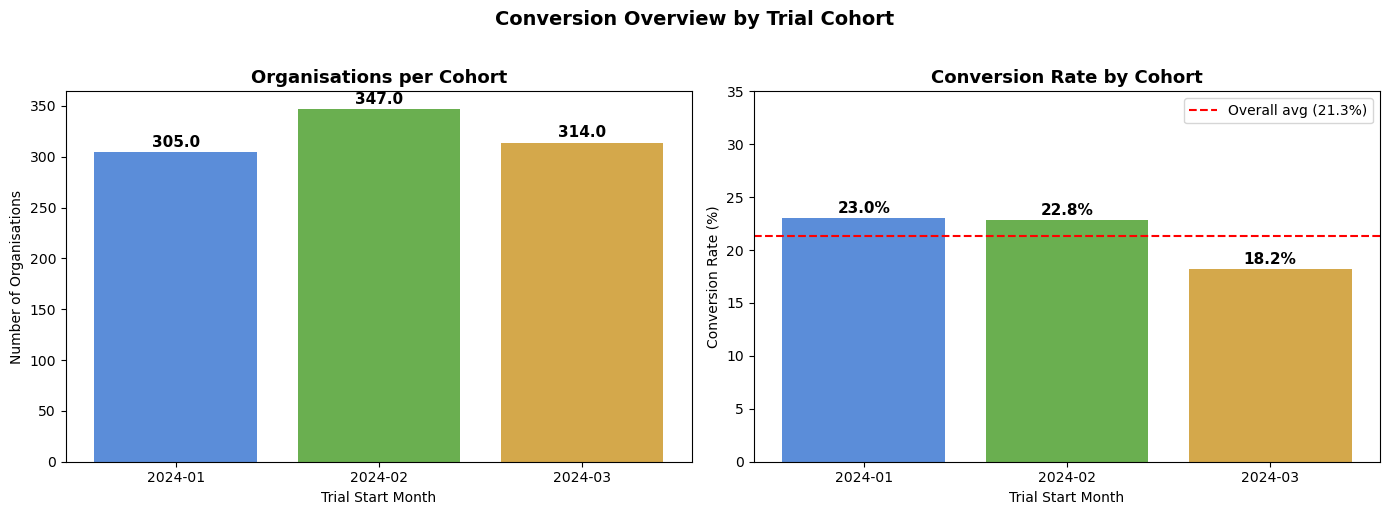

Chart saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: total orgs per cohort (size of each cohort)
axes[0].bar(
    cohort_conv.index,
    cohort_conv["total_orgs"],
    color=["#5b8dd9", "#6aaf50", "#d4a84b"],
    edgecolor="none"
)
axes[0].set_title("Organisations per Cohort", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Trial Start Month")
axes[0].set_ylabel("Number of Organisations")

for i, (idx, row) in enumerate(cohort_conv.iterrows()):
    axes[0].text(i, row["total_orgs"] + 5, str(row["total_orgs"]),
                 ha="center", fontsize=11, fontweight="bold")

# Right chart: conversion rate per cohort
bars = axes[1].bar(
    cohort_conv.index,
    cohort_conv["conversion_rate"],
    color=["#5b8dd9", "#6aaf50", "#d4a84b"],
    edgecolor="none"
)
axes[1].axhline(y=conv_rate, color="red", linestyle="--",
                linewidth=1.5, label=f"Overall avg ({conv_rate:.1f}%)")
axes[1].set_title("Conversion Rate by Cohort", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Trial Start Month")
axes[1].set_ylabel("Conversion Rate (%)")
axes[1].legend()
axes[1].set_ylim(0, 35)

for i, (idx, row) in enumerate(cohort_conv.iterrows()):
    axes[1].text(i, row["conversion_rate"] + 0.5,
                 f"{row['conversion_rate']}%",
                 ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Conversion Overview by Trial Cohort",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("conversion_by_cohort.png", bbox_inches="tight", dpi=150)
plt.show()
print("Chart saved.")

In [37]:
# ── Calculate days from trial start to conversion
# We only look at orgs that actually converted.
# days_to_convert = the date they converted minus the date their trial started, expressed in whole days.

converted_df = org_df[org_df["converted"] == True].copy()

converted_df["days_to_convert"] = (
    converted_df["converted_at"] - converted_df["trial_start"]
).dt.days

print("── Time to Convert (days) ───")
print(f"Converted orgs:  {len(converted_df)}")
print(f"Median:          {converted_df['days_to_convert'].median():.0f} days")
print(f"Mean:            {converted_df['days_to_convert'].mean():.1f} days")
print(f"Min:             {converted_df['days_to_convert'].min():.0f} days")
print(f"Max:             {converted_df['days_to_convert'].max():.0f} days")
print(f"\nDistribution:")
print(converted_df["days_to_convert"].describe().round(1))

── Time to Convert (days) ───
Converted orgs:  206
Median:          30 days
Mean:            30.3 days
Min:             14 days
Max:             64 days

Distribution:
count    206.0
mean      30.3
std        8.2
min       14.0
25%       25.0
50%       30.0
75%       36.0
max       64.0
Name: days_to_convert, dtype: float64


In [36]:
# ── Bucket conversions into time bands ──
# Instead of just looking at raw days, we group conversions into bands: within the first week, within two weeks, etc.
# This gives the product team a more actionable picture for example "50% of converters decide within 7 days"
# is a much more useful insight than a median number.

def time_band(days):
    if days <= 7:   return "0–7 days"
    elif days <= 14: return "8–14 days"
    elif days <= 21: return "15–21 days"
    elif days <= 30: return "22–30 days"
    else:            return "30+ days"

converted_df["time_band"] = converted_df["days_to_convert"].apply(time_band)

band_order = ["0–7 days", "8–14 days", "15–21 days", "22–30 days", "30+ days"]
band_counts = (
    converted_df["time_band"]
    .value_counts()
    .reindex(band_order)
    .fillna(0)
    .astype(int)
)
band_pct = (band_counts / len(converted_df) * 100).round(1)

print("\n── Conversions by Time Band ──")
for band, count, pct in zip(band_order, band_counts, band_pct):
    print(f"  {band:<14}  {count:>3} orgs  ({pct}%)")


── Conversions by Time Band ──
  0–7 days          0 orgs  (0.0%)
  8–14 days         3 orgs  (1.5%)
  15–21 days       28 orgs  (13.6%)
  22–30 days       74 orgs  (35.9%)
  30+ days        101 orgs  (49.0%)


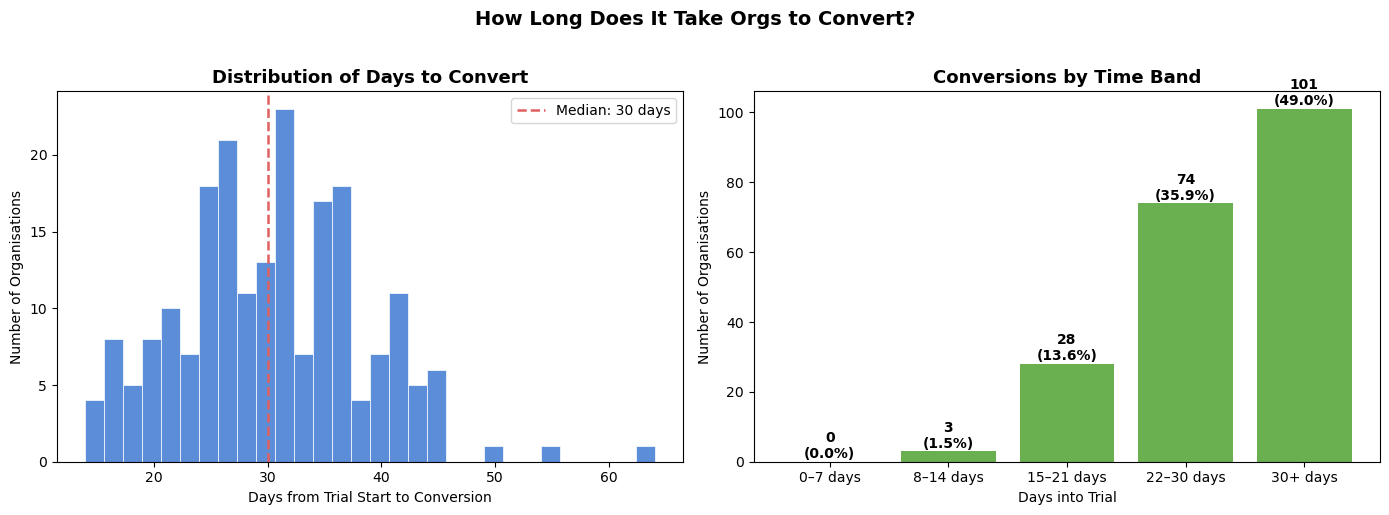

Chart saved.


In [15]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of raw days_to_convert
axes[0].hist(
    converted_df["days_to_convert"].dropna(),
    bins=30,
    color="#5b8dd9",
    edgecolor="white",
    linewidth=0.5
)
axes[0].axvline(
    converted_df["days_to_convert"].median(),
    color="#e06060", linestyle="--", linewidth=1.8,
    label=f"Median: {converted_df['days_to_convert'].median():.0f} days"
)
axes[0].set_title("Distribution of Days to Convert", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Days from Trial Start to Conversion")
axes[0].set_ylabel("Number of Organisations")
axes[0].legend()

# Right: time band bar chart
axes[1].bar(
    band_order,
    band_counts.values,
    color="#6aaf50",
    edgecolor="none"
)
for i, (count, pct) in enumerate(zip(band_counts.values, band_pct.values)):
    axes[1].text(i, count + 1, f"{count}\n({pct}%)",
                 ha="center", fontsize=10, fontweight="bold")

axes[1].set_title("Conversions by Time Band", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Days into Trial")
axes[1].set_ylabel("Number of Organisations")

plt.suptitle("How Long Does It Take Orgs to Convert?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("time_to_convert.png", bbox_inches="tight", dpi=150)
plt.show()
print("Chart saved.")

In [38]:
# TRIAL GOAL FUNNEL

# This is one of the most important charts for the product team. It shows how many orgs made it through each step
# of the activation journey, from starting a trial, to hitting Goal 1, Goal 2, Goal 3, and finally full Trial Activation (all three goals completed).

# This funnel like this immediately shows where the biggest drop-offs are. If 90% of orgs hit Goal 1 but only 11%
# hit Goal 2, that tells the product team exactly where to focus their onboarding efforts.


# ── Build the funnel numbers ───
# Each stage is a count of orgs that reached that point.
# Note: these are not sequential filters, an org can hit Goal 3 without hitting Goal 2. Each number is independent.
# The funnel shows the full picture of goal adoption rates.

total          = len(org_df)
goal1_orgs     = org_df["goal1_met"].sum()
goal2_orgs     = org_df["goal2_met"].sum()
goal3_orgs     = org_df["goal3_met"].sum()
activated_orgs = org_df["trial_activated"].sum()

funnel_data = {
    "Started Trial":          total,
    "Goal 1 — Shift Created": goal1_orgs,
    "Goal 2 — Template Used": goal2_orgs,
    "Goal 3 — Punched In":    goal3_orgs,
    "Trial Activated":        activated_orgs,
}

print("── Trial Goal Funnel ──")
print(f"{'Stage':<30} {'Orgs':>6}  {'% of Total':>10}  {'Drop-off':>10}")
print("─" * 62)
prev = total
for stage, count in funnel_data.items():
    pct      = count / total * 100
    dropoff  = prev - count
    drop_pct = dropoff / prev * 100 if prev > 0 else 0
    print(f"{stage:<30} {count:>6}  {pct:>9.1f}%  {f'-{dropoff} ({drop_pct:.1f}%)':>12}")
    prev = count

── Trial Goal Funnel ──
Stage                            Orgs  % of Total    Drop-off
──────────────────────────────────────────────────────────────
Started Trial                     966      100.0%     -0 (0.0%)
Goal 1 — Shift Created            563       58.3%  -403 (41.7%)
Goal 2 — Template Used            108       11.2%  -455 (80.8%)
Goal 3 — Punched In               211       21.8%  --103 (-95.4%)
Trial Activated                    56        5.8%  -155 (73.5%)


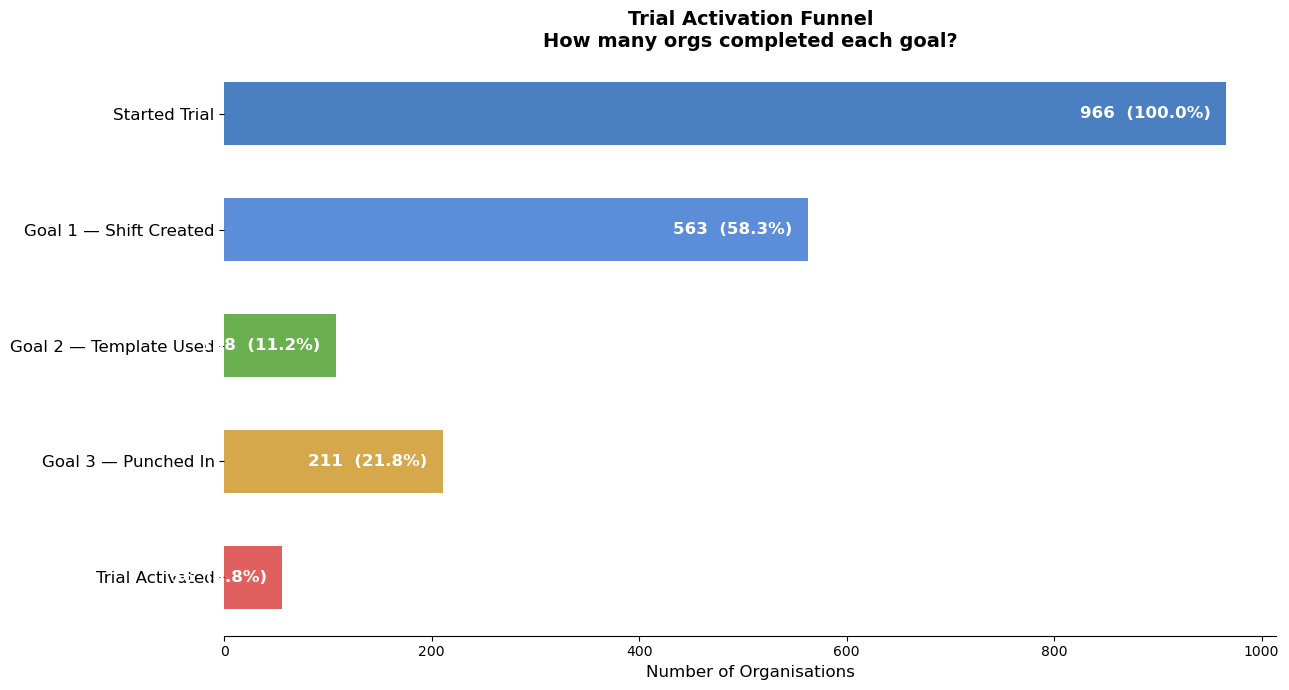

Chart saved.


In [39]:
# ── Visualise the funnel ──
# Each bar is proportional to the number of orgs at that stage. The percentage labels show both the % of total and the absolute count.

stages = list(funnel_data.keys())
counts = list(funnel_data.values())
pcts   = [c / total * 100 for c in counts]

# Colour gets darker as orgs progress through the funnel
colors = ["#4a7fc1", "#5b8dd9", "#6aaf50", "#d4a84b", "#e06060"]

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    stages[::-1],   # reverse so Stage 1 is at the top
    counts[::-1],
    color=colors[::-1],
    edgecolor="none",
    height=0.55
)

# Add count + percentage labels inside each bar
for bar, count, pct in zip(bars, counts[::-1], pcts[::-1]):
    ax.text(
        bar.get_width() - 15,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}  ({pct:.1f}%)",
        va="center", ha="right",
        fontsize=12, fontweight="bold",
        color="white"
    )

ax.set_xlabel("Number of Organisations", fontsize=12)
ax.set_title("Trial Activation Funnel\nHow many orgs completed each goal?",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, total * 1.05)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.savefig("trial_goal_funnel.png", bbox_inches="tight", dpi=150)
plt.show()
print("Chart saved.")

In [40]:
# ── Goal completion overlap ───

# How many orgs hit exactly 1 goal, 2 goals, or all 3? This tells us whether orgs are completing goals in combination or mostly in isolation.

org_df["goals_completed"] = (
    org_df["goal1_met"] +
    org_df["goal2_met"] +
    org_df["goal3_met"]
)

overlap = org_df["goals_completed"].value_counts().sort_index()
overlap_pct = (overlap / total * 100).round(1)

print("\n── Goals Completed per Organisation ──")
labels = {0: "No goals", 1: "1 goal only", 2: "2 goals", 3: "All 3 goals (Activated)"}
for k, count in overlap.items():
    print(f"  {labels[k]:<28} {count:>4} orgs  ({overlap_pct[k]}%)")


── Goals Completed per Organisation ──
  No goals                      369 orgs  (38.2%)
  1 goal only                   368 orgs  (38.1%)
  2 goals                       173 orgs  (17.9%)
  All 3 goals (Activated)        56 orgs  (5.8%)


In [41]:
# FEATURE & ACTIVITY ADOPTION

# Which features are actually being used during trials? This tells the product team where orgs are spending their
# time and which parts of the platform are being ignored. A feature with low adoption is either hard to find,
# hard to use or not valuable enough, all worth knowing.

# ── Calculate adoption rate per activity ───

# Adoption rate = % of orgs that used this activity at least once during their trial. We use org_df (one row per org)
# so we are counting orgs, not individual events.

activity_cols = [col for col in org_df.columns
                 if any(col.startswith(x) for x in [
                     "Scheduling", "PunchClock", "Absence",
                     "Timesheets", "Communication", "Mobile",
                     "Shift", "Break", "Revenue", "Integration"])]

adoption = (
    (org_df[activity_cols] > 0)
    .mean() * 100
).round(1).sort_values(ascending=False)

adoption_df = pd.DataFrame({
    "activity":       adoption.index,
    "adoption_rate":  adoption.values,
    "orgs_used":      (org_df[activity_cols] > 0).sum().values,
    "median_usage":   org_df[activity_cols].median().round(1).values,
    "mean_usage":     org_df[activity_cols].mean().round(1).values,
})

print("── Activity Adoption Rates (% of orgs that used it) ──")
print(adoption_df.to_string(index=False))

── Activity Adoption Rates (% of orgs that used it) ──
                              activity  adoption_rate  orgs_used  median_usage  mean_usage
              Scheduling.Shift.Created           87.8         35           0.0         0.3
                Mobile.Schedule.Loaded           47.2         39           0.0         0.4
    Scheduling.Shift.AssignmentChanged           35.5         14           0.0         0.1
                  PunchClock.PunchedIn           21.8          6           0.0         0.2
             Scheduling.Shift.Approved           20.7          6           0.0         0.2
         Communication.Message.Created           15.0        145           0.0         1.6
Scheduling.Template.ApplyModal.Applied           11.2          6           0.0         0.0
           Scheduling.Availability.Set            6.1        456           0.0        51.3
              ShiftDetails.View.Opened            4.7          7           0.0         0.1
   Scheduling.OpenShiftRequest.Crea

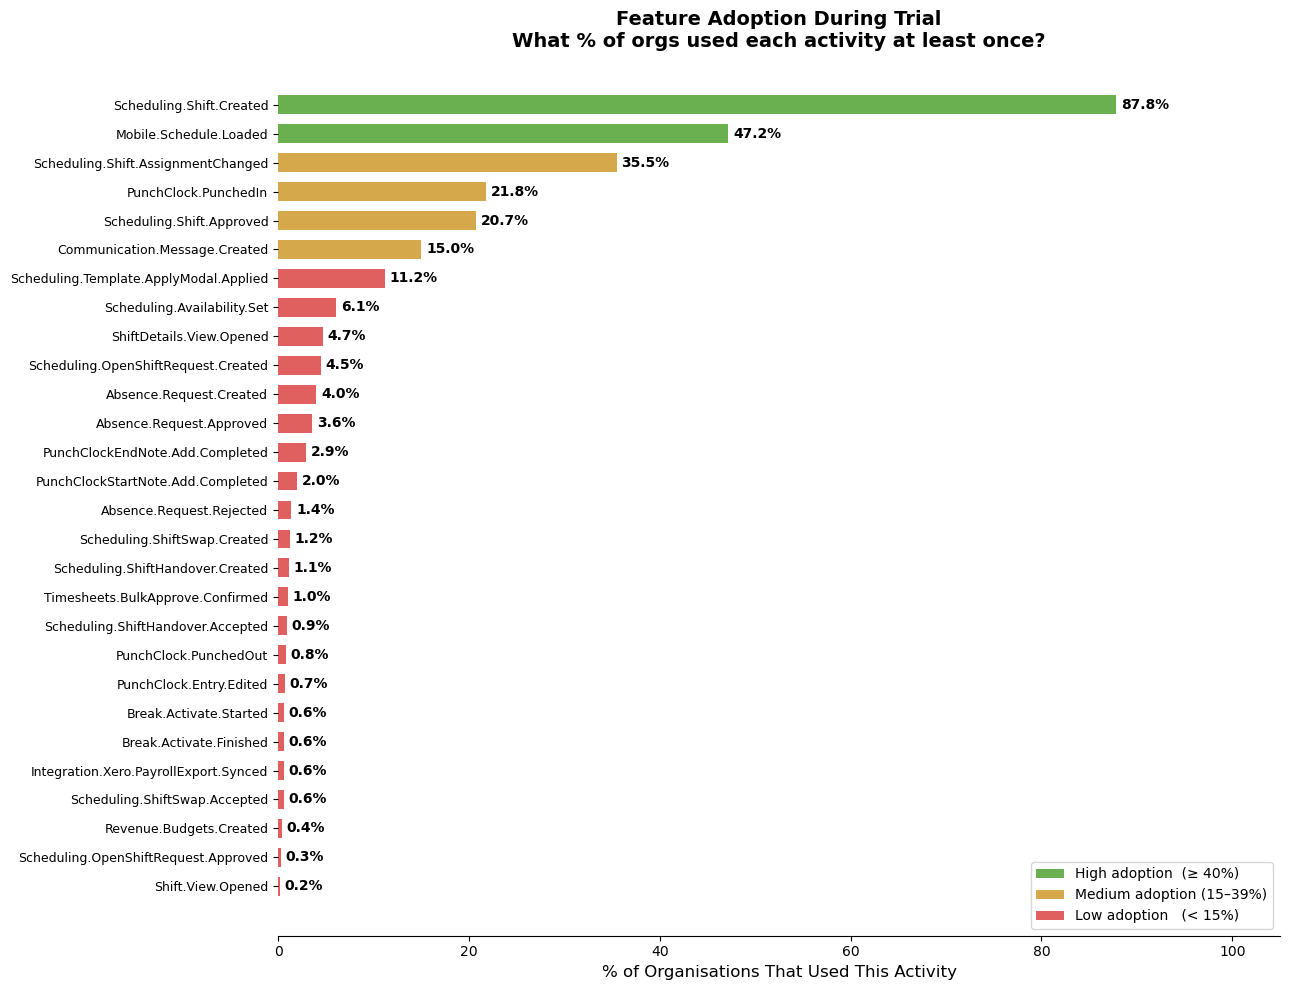

Chart saved.


In [42]:
# ── Visualise adoption rates ───

# A horizontal bar chart ranked from highest to lowest adoption. The colour coding splits activities into
# high adoption (green), medium (yellow) and low (red) so the product team can immediately see where to focus.

fig, ax = plt.subplots(figsize=(13, 10))

# Assign colours based on adoption rate thresholds
colors = [
    "#6aaf50" if r >= 40
    else "#d4a84b" if r >= 15
    else "#e06060"
    for r in adoption_df["adoption_rate"]
]

bars = ax.barh(
    adoption_df["activity"][::-1],
    adoption_df["adoption_rate"][::-1],
    color=colors[::-1],
    edgecolor="none",
    height=0.65
)

# Add percentage labels at the end of each bar
for bar, rate in zip(bars, adoption_df["adoption_rate"][::-1]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{rate}%",
        va="center", ha="left",
        fontsize=10, fontweight="bold"
    )

# Add a legend explaining the colour bands
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#6aaf50", label="High adoption  (≥ 40%)"),
    Patch(facecolor="#d4a84b", label="Medium adoption (15–39%)"),
    Patch(facecolor="#e06060", label="Low adoption   (< 15%)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10)

ax.set_xlabel("% of Organisations That Used This Activity", fontsize=12)
ax.set_title("Feature Adoption During Trial\nWhat % of orgs used each activity at least once?",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, 105)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig("feature_adoption.png", bbox_inches="tight", dpi=150)
plt.show()
print("Chart saved.")

In [43]:
# ── Module-level adoption summary ──

# Group individual activities into their parent modules. This gives a higher level view, instead of 28 individual
# activities the product team sees 5 core modules and how many orgs engaged with each one.

module_map = {
    "Scheduling":     [c for c in activity_cols if c.startswith("Scheduling")],
    "PunchClock":     [c for c in activity_cols if c.startswith("PunchClock")],
    "Absence":        [c for c in activity_cols if c.startswith("Absence")],
    "Timesheets":     [c for c in activity_cols if c.startswith("Timesheets")],
    "Communication":  [c for c in activity_cols if c.startswith("Communication")],
}

print("\n── Module-Level Adoption ──")
print(f"{'Module':<16} {'Orgs Used':>10}  {'Adoption Rate':>14}")
print("─" * 44)
for module, cols in module_map.items():
    used = (org_df[cols] > 0).any(axis=1).sum()
    rate = used / total * 100
    print(f"{module:<16} {used:>10}  {rate:>13.1f}%")


── Module-Level Adoption ──
Module            Orgs Used   Adoption Rate
────────────────────────────────────────────
Scheduling              852           88.2%
PunchClock              211           21.8%
Absence                  40            4.1%
Timesheets               10            1.0%
Communication           145           15.0%


In [44]:

# ENGAGEMENT DEPTH

# Adoption tells us which features orgs tried.
# Engagement depth tells us how intensely they used them. An org that created 1 shift is very different from one
# that created 50. This looks at the distribution of total events, days active, and unique activities
# across all 966 orgs, split by converted vs not.

# ── Summary statistics by conversion status ──
# We want to know: do converted orgs engage more deeply?
# We already know from Task 1 that the medians are similar,
# but the full distribution might tell a richer story.

engagement_metrics = [
    "total_events",
    "unique_activities",
    "days_active",
    "first_event_day",
    "last_event_day",
]

print("── Engagement Depth by Conversion Status ────────")
for metric in engagement_metrics:
    conv_med  = org_df[org_df["converted"]==True][metric].median()
    nconv_med = org_df[org_df["converted"]==False][metric].median()
    conv_mean  = org_df[org_df["converted"]==True][metric].mean()
    nconv_mean = org_df[org_df["converted"]==False][metric].mean()
    print(f"\n  {metric}")
    print(f"    Converters     — median: {conv_med:>6.1f}  mean: {conv_mean:>6.1f}")
    print(f"    Non-converters — median: {nconv_med:>6.1f}  mean: {nconv_mean:>6.1f}")

── Engagement Depth by Conversion Status ────────

  total_events
    Converters     — median:    8.0  mean:  107.9
    Non-converters — median:    8.0  mean:  106.1

  unique_activities
    Converters     — median:    2.0  mean:    2.8
    Non-converters — median:    2.0  mean:    2.8

  days_active
    Converters     — median:    1.0  mean:    4.2
    Non-converters — median:    1.0  mean:    4.2

  first_event_day
    Converters     — median:    0.0  mean:    0.7
    Non-converters — median:    0.0  mean:    0.8

  last_event_day
    Converters     — median:    0.0  mean:    7.2
    Non-converters — median:    0.0  mean:    6.5


In [45]:
# ── How quickly did orgs start engaging? ──

# first_event_day = how many days after trial start the org  logged their very first event. Day 0 means they started on the same day their trial began.
# Orgs that start immediately are more likely to be serious about evaluating the product, this is really worth tracking.

print("\n── First Event Day Distribution ───")
print(f"  Day 0 (same day as trial start):  "
      f"{(org_df['first_event_day']==0).sum()} orgs "
      f"({(org_df['first_event_day']==0).mean()*100:.1f}%)")
print(f"  Day 1–3:  "
      f"{org_df['first_event_day'].between(1,3).sum()} orgs "
      f"({org_df['first_event_day'].between(1,3).mean()*100:.1f}%)")
print(f"  Day 4–7:  "
      f"{org_df['first_event_day'].between(4,7).sum()} orgs "
      f"({org_df['first_event_day'].between(4,7).mean()*100:.1f}%)")
print(f"  Day 8+:   "
      f"{(org_df['first_event_day']>7).sum()} orgs "
      f"({(org_df['first_event_day']>7).mean()*100:.1f}%)")


── First Event Day Distribution ───
  Day 0 (same day as trial start):  882 orgs (91.3%)
  Day 1–3:  25 orgs (2.6%)
  Day 4–7:  21 orgs (2.2%)
  Day 8+:   38 orgs (3.9%)


In [46]:
# ── Stickiness score ───

# Stickiness = days_active / total trial days
# A score of 1.0 means the org was active every single day of their trial. A score of 0.1 means they only showed up
# on 10% of days. This is a standard product engagement metric that tells us how embedded the product became 
# in the org's day-to-day routine during the trial.

org_df["trial_length"] = (
    (org_df["trial_end"] - org_df["trial_start"]).dt.days + 1
)
org_df["stickiness"] = (
    org_df["days_active"] / org_df["trial_length"]
).round(3)

print("\n── Stickiness Score (days_active / trial_length) ─")
print(f"  Overall median:         {org_df['stickiness'].median():.3f}")
print(f"  Converters median:      {org_df[org_df['converted']==True]['stickiness'].median():.3f}")
print(f"  Non-converters median:  {org_df[org_df['converted']==False]['stickiness'].median():.3f}")
print(f"\n  Distribution:")
print(f"  Very sticky  (≥ 0.5):  {(org_df['stickiness']>=0.5).sum()} orgs  "
      f"({(org_df['stickiness']>=0.5).mean()*100:.1f}%)")
print(f"  Moderate     (0.2–0.5): {org_df['stickiness'].between(0.2,0.5).sum()} orgs  "
      f"({org_df['stickiness'].between(0.2,0.5).mean()*100:.1f}%)")
print(f"  Low          (< 0.2):  {(org_df['stickiness']<0.2).sum()} orgs  "
      f"({(org_df['stickiness']<0.2).mean()*100:.1f}%)")


── Stickiness Score (days_active / trial_length) ─
  Overall median:         0.032
  Converters median:      0.032
  Non-converters median:  0.032

  Distribution:
  Very sticky  (≥ 0.5):  95 orgs  (9.8%)
  Moderate     (0.2–0.5): 56 orgs  (5.8%)
  Low          (< 0.2):  815 orgs  (84.4%)


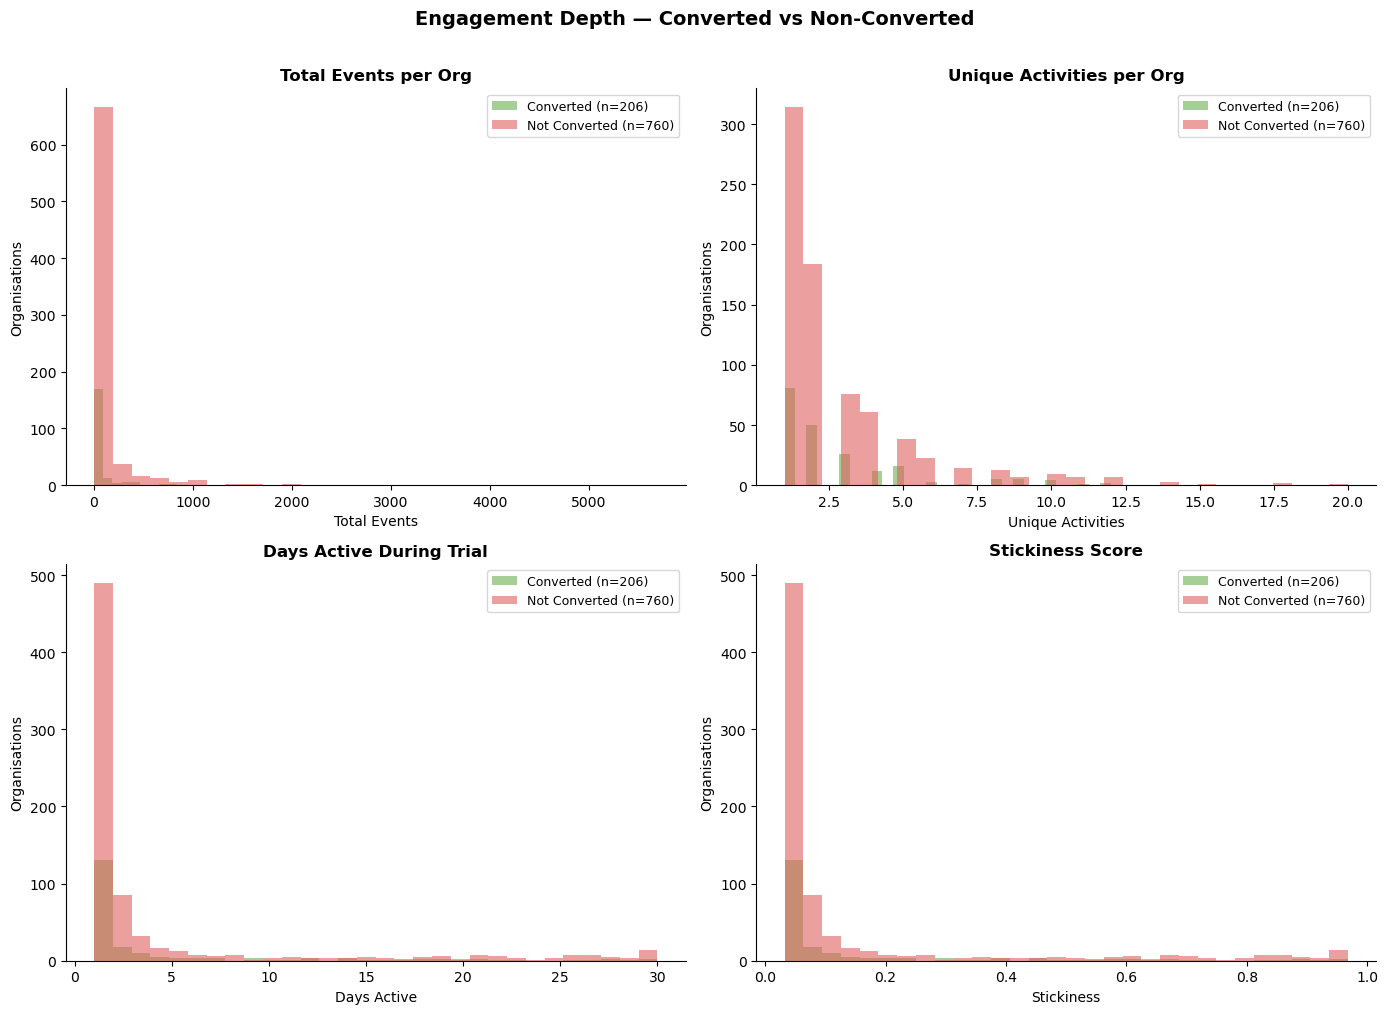

Chart saved.


In [47]:
# ── Visualise engagement depth ────

# Four charts showing the distributions of the key engagement metrics, split by conversion status. Green = converted, Red = not converted.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plots = [
    ("total_events",      "Total Events per Org",        50),
    ("unique_activities", "Unique Activities per Org",    1),
    ("days_active",       "Days Active During Trial",     1),
    ("stickiness",        "Stickiness Score",             0.05),
]

for ax, (metric, title, binwidth) in zip(axes, plots):
    for status, color, label in [
        (True,  "#6aaf50", "Converted"),
        (False, "#e06060", "Not Converted"),
    ]:
        subset = org_df[org_df["converted"]==status][metric].dropna()
        ax.hist(
            subset,
            bins=30,
            alpha=0.6,
            color=color,
            label=f"{label} (n={len(subset)})",
            edgecolor="none"
        )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(metric.replace("_", " ").title())
    ax.set_ylabel("Organisations")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Engagement Depth — Converted vs Non-Converted",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("engagement_depth.png", bbox_inches="tight", dpi=150)
plt.show()
print("Chart saved.")

In [48]:

# PRODUCT METRICS

# This section pulls together the key metrics a product team would track on a dashboard to monitor trial health.
# These are derived directly from the data and give a concise, numbers-first summary of how trials are performing.


# ── Metric 1: Trial Activation Rate ──

# The % of trialling orgs that completed all 3 goals.
# This is the north star metric for the activation model.

activation_rate = org_df["trial_activated"].mean() * 100

# ── Metric 2: Goal Completion Rates ───

# What % of orgs completed each individual goal?
# Helps identify which goals are easy vs hard to reach.

goal1_rate = org_df["goal1_met"].mean() * 100
goal2_rate = org_df["goal2_met"].mean() * 100
goal3_rate = org_df["goal3_met"].mean() * 100

# ── Metric 3: Activation-to-Conversion Rate ───
# Of the orgs that trial-activated, what % converted?
# This validates whether activation predicts conversion.

activated_mask       = org_df["trial_activated"] == 1
activation_conv_rate = org_df[activated_mask]["converted"].mean() * 100
non_activation_conv  = org_df[~activated_mask]["converted"].mean() * 100

# ── Metric 4: Average Time to First Event ──
# How quickly do orgs engage after their trial starts?
# A lower number means faster time to value.

avg_first_event = org_df["first_event_day"].mean()
med_first_event = org_df["first_event_day"].median()

# ── Metric 5: Feature Breadth ────
# Average number of unique activities per org during trial.
# Higher = more of the platform being explored.

avg_breadth  = org_df["unique_activities"].mean()
conv_breadth = org_df[org_df["converted"]==True]["unique_activities"].mean()
nconv_breadth= org_df[org_df["converted"]==False]["unique_activities"].mean()

# ── Metric 6: Trial Completion Rate ──
# % of orgs that were still active in the final week
# of their trial (days 23–30). Measures trial persistence.

org_df["active_final_week"] = (org_df["last_event_day"] >= 23).astype(int)
final_week_rate = org_df["active_final_week"].mean() * 100

# ── Metric 7: Average Events per Active Org ──
# How many actions does the average org take during their
# trial? A proxy for how deeply they engage with the product.

avg_events_all   = org_df["total_events"].mean()
avg_events_conv  = org_df[org_df["converted"]==True]["total_events"].mean()
avg_events_nconv = org_df[org_df["converted"]==False]["total_events"].mean()

print("=" * 58)
print("  PRODUCT METRICS DASHBOARD")
print("=" * 58)

print(f"\n  ACTIVATION")
print(f"  Trial Activation Rate          {activation_rate:.1f}%")
print(f"  Goal 1 Completion Rate         {goal1_rate:.1f}%")
print(f"  Goal 2 Completion Rate         {goal2_rate:.1f}%")
print(f"  Goal 3 Completion Rate         {goal3_rate:.1f}%")

print(f"\n  CONVERSION")
print(f"  Overall Conversion Rate        {conv_rate:.1f}%")
print(f"  Activated → Converted          {activation_conv_rate:.1f}%")
print(f"  Not Activated → Converted      {non_activation_conv:.1f}%")

print(f"\n  ENGAGEMENT")
print(f"  Avg Time to First Event        {avg_first_event:.1f} days")
print(f"  Median Time to First Event     {med_first_event:.0f} days")
print(f"  Avg Unique Activities / Org    {avg_breadth:.1f}")
print(f"    Converters                   {conv_breadth:.1f}")
print(f"    Non-converters               {nconv_breadth:.1f}")
print(f"  Avg Events / Org               {avg_events_all:.0f}")
print(f"    Converters                   {avg_events_conv:.0f}")
print(f"    Non-converters               {avg_events_nconv:.0f}")

print(f"\n  RETENTION PROXY")
print(f"  Active in Final Week (day 23+) {final_week_rate:.1f}%")
print(f"  Overall Stickiness Median      {org_df['stickiness'].median():.3f}")
print(f"  Very Sticky Orgs (≥ 0.5)       {(org_df['stickiness']>=0.5).sum()} ({(org_df['stickiness']>=0.5).mean()*100:.1f}%)")

print("\n" + "=" * 58)

  PRODUCT METRICS DASHBOARD

  ACTIVATION
  Trial Activation Rate          5.8%
  Goal 1 Completion Rate         58.3%
  Goal 2 Completion Rate         11.2%
  Goal 3 Completion Rate         21.8%

  CONVERSION
  Overall Conversion Rate        21.3%
  Activated → Converted          23.2%
  Not Activated → Converted      21.2%

  ENGAGEMENT
  Avg Time to First Event        0.8 days
  Median Time to First Event     0 days
  Avg Unique Activities / Org    2.8
    Converters                   2.8
    Non-converters               2.8
  Avg Events / Org               107
    Converters                   108
    Non-converters               106

  RETENTION PROXY
  Active in Final Week (day 23+) 18.3%
  Overall Stickiness Median      0.032
  Very Sticky Orgs (≥ 0.5)       95 (9.8%)



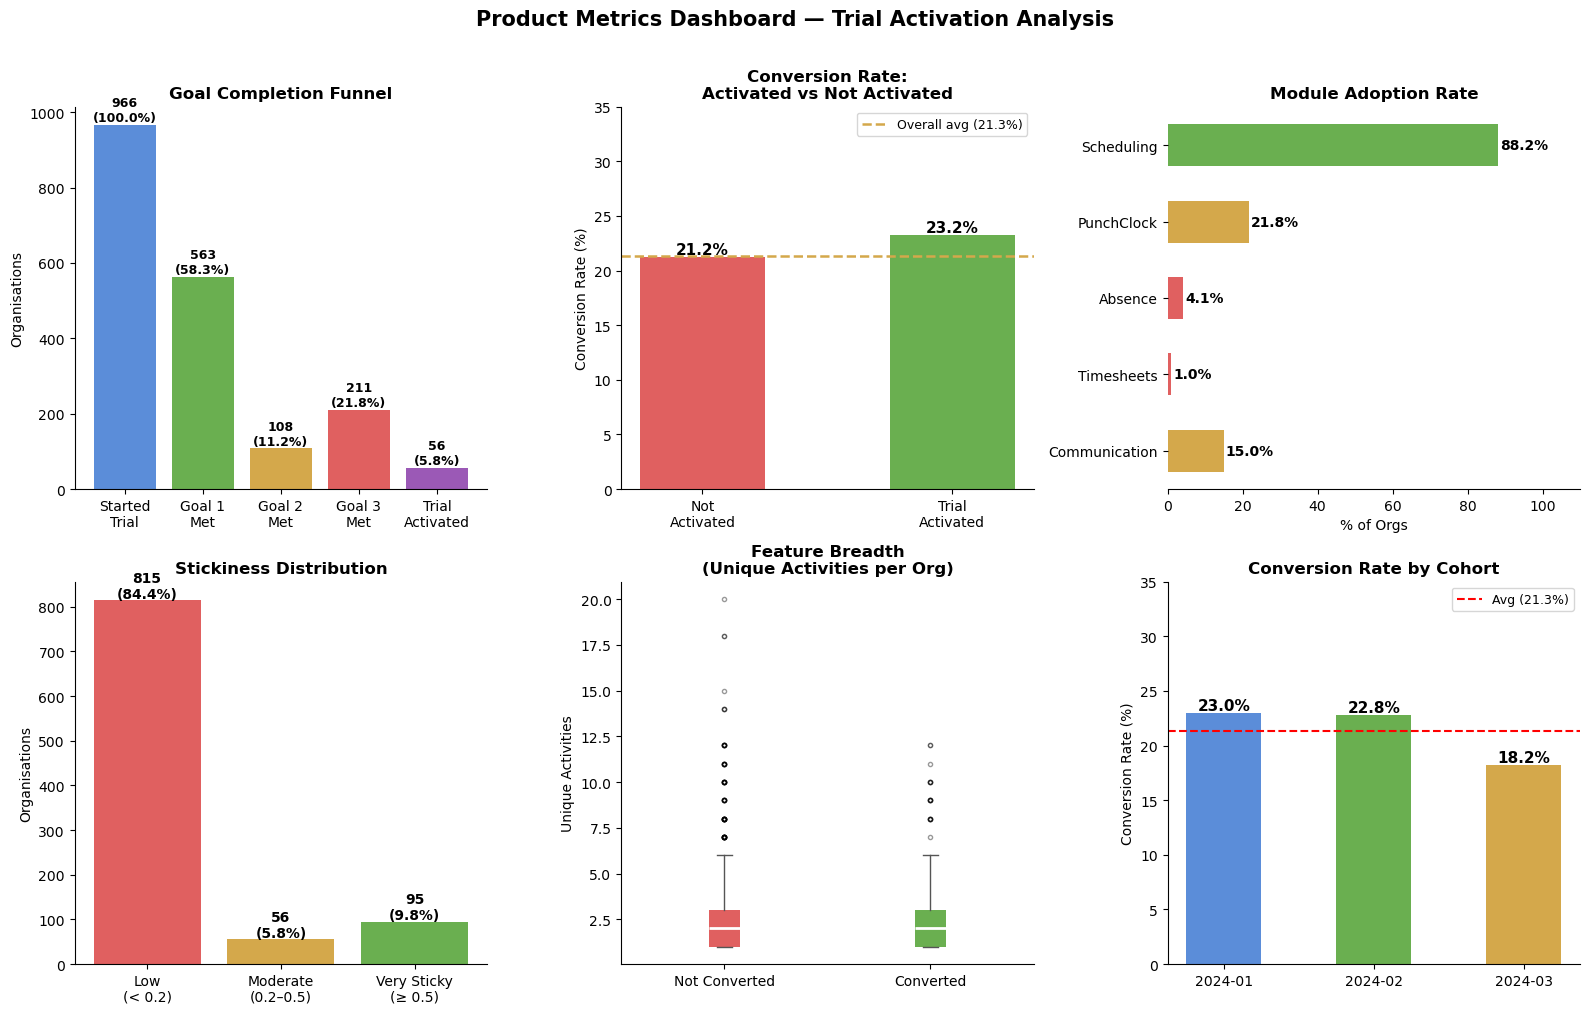

Dashboard saved.


In [49]:
# ── Visualise the product metrics dashboard ───

# A clean summary chart showing the headline metrics in one
# place. This is the kind of view a product manager would
# want pinned to their wall.

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# ── Chart 1: Funnel summary ───────────────────────────────────
funnel_labels = ["Started\nTrial", "Goal 1\nMet", "Goal 2\nMet",
                 "Goal 3\nMet", "Trial\nActivated"]
funnel_values = [total, goal1_orgs, goal2_orgs, goal3_orgs, activated_orgs]
funnel_colors = ["#5b8dd9","#6aaf50","#d4a84b","#e06060","#9b59b6"]

axes[0].bar(funnel_labels, funnel_values, color=funnel_colors, edgecolor="none")
for i, (v, p) in enumerate(zip(funnel_values, [v/total*100 for v in funnel_values])):
    axes[0].text(i, v + 10, f"{v}\n({p:.1f}%)", ha="center",
                 fontsize=9, fontweight="bold")
axes[0].set_title("Goal Completion Funnel", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Organisations")
axes[0].spines[["top","right"]].set_visible(False)

# ── Chart 2: Conversion rate comparison ──────────────────────
conv_labels  = ["Not\nActivated", "Trial\nActivated"]
conv_values  = [non_activation_conv, activation_conv_rate]
conv_colors  = ["#e06060", "#6aaf50"]

bars = axes[1].bar(conv_labels, conv_values, color=conv_colors,
                   edgecolor="none", width=0.5)
axes[1].axhline(y=conv_rate, color="#d4a84b", linestyle="--",
                linewidth=1.8, label=f"Overall avg ({conv_rate:.1f}%)")
for bar, val in zip(bars, conv_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("Conversion Rate:\nActivated vs Not Activated",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Conversion Rate (%)")
axes[1].set_ylim(0, 35)
axes[1].legend(fontsize=9)
axes[1].spines[["top","right"]].set_visible(False)

# ── Chart 3: Module adoption ──────────────────────────────────
modules      = ["Scheduling", "PunchClock", "Absence", "Timesheets", "Communication"]
module_rates = []
for mod in modules:
    cols = [c for c in activity_cols if c.startswith(mod)]
    rate = (org_df[cols] > 0).any(axis=1).mean() * 100
    module_rates.append(round(rate, 1))

mod_colors = ["#6aaf50" if r >= 40 else "#d4a84b" if r >= 15
              else "#e06060" for r in module_rates]
axes[2].barh(modules[::-1], module_rates[::-1],
             color=mod_colors[::-1], edgecolor="none", height=0.55)
for i, rate in enumerate(module_rates[::-1]):
    axes[2].text(rate + 0.5, i, f"{rate}%",
                 va="center", fontsize=10, fontweight="bold")
axes[2].set_title("Module Adoption Rate", fontsize=12, fontweight="bold")
axes[2].set_xlabel("% of Orgs")
axes[2].set_xlim(0, 110)
axes[2].spines[["top","right","left"]].set_visible(False)

# ── Chart 4: Stickiness distribution ─────────────────────────
stick_labels = ["Low\n(< 0.2)", "Moderate\n(0.2–0.5)", "Very Sticky\n(≥ 0.5)"]
stick_counts = [
    (org_df["stickiness"] < 0.2).sum(),
    org_df["stickiness"].between(0.2, 0.5).sum(),
    (org_df["stickiness"] >= 0.5).sum(),
]
axes[3].bar(stick_labels, stick_counts,
            color=["#e06060","#d4a84b","#6aaf50"], edgecolor="none")
for i, v in enumerate(stick_counts):
    axes[3].text(i, v + 5, f"{v}\n({v/total*100:.1f}%)",
                 ha="center", fontsize=10, fontweight="bold")
axes[3].set_title("Stickiness Distribution", fontsize=12, fontweight="bold")
axes[3].set_ylabel("Organisations")
axes[3].spines[["top","right"]].set_visible(False)

# ── Chart 5: Feature breadth by conversion status ────────────
breadth_data = [
    org_df[org_df["converted"]==False]["unique_activities"],
    org_df[org_df["converted"]==True]["unique_activities"],
]
bp = axes[4].boxplot(
    breadth_data,
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    boxprops=dict(linewidth=0),
    whiskerprops=dict(color="#555"),
    capprops=dict(color="#555"),
    flierprops=dict(marker="o", markersize=3, alpha=0.4)
)
bp["boxes"][0].set_facecolor("#e06060")
bp["boxes"][1].set_facecolor("#6aaf50")
axes[4].set_xticks([1,2])
axes[4].set_xticklabels(["Not Converted", "Converted"])
axes[4].set_title("Feature Breadth\n(Unique Activities per Org)",
                  fontsize=12, fontweight="bold")
axes[4].set_ylabel("Unique Activities")
axes[4].spines[["top","right"]].set_visible(False)

# ── Chart 6: Cohort conversion rates ─────────────────────────
axes[5].bar(
    cohort_conv.index,
    cohort_conv["conversion_rate"],
    color=["#5b8dd9","#6aaf50","#d4a84b"],
    edgecolor="none", width=0.5
)
axes[5].axhline(y=conv_rate, color="red", linestyle="--",
                linewidth=1.5, label=f"Avg ({conv_rate:.1f}%)")
for i, (idx, row) in enumerate(cohort_conv.iterrows()):
    axes[5].text(i, row["conversion_rate"] + 0.3,
                 f"{row['conversion_rate']}%",
                 ha="center", fontsize=11, fontweight="bold")
axes[5].set_title("Conversion Rate by Cohort",
                  fontsize=12, fontweight="bold")
axes[5].set_ylabel("Conversion Rate (%)")
axes[5].set_ylim(0, 35)
axes[5].legend(fontsize=9)
axes[5].spines[["top","right"]].set_visible(False)

plt.suptitle("Product Metrics Dashboard — Trial Activation Analysis",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("product_metrics_dashboard.png", bbox_inches="tight", dpi=150)
plt.show()
print("Dashboard saved.")